# EEG 信号处理完整流程

从原始 GDF 数据到分类评估的完整 pipeline
包括：预处理 → 特征提取 → 分类 → 评估

In [4]:
import sys
from pathlib import Path

# 添加项目路径以便导入模块
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'code'))

print(f"项目根目录: {project_root}")
print("✅ 路径配置完成")
print(f"当前工作目录：{str(project_root / 'code')}")

项目根目录: /home/eliorfoy/code/Graduation-Design
✅ 路径配置完成
当前工作目录：/home/eliorfoy/code/Graduation-Design/code


In [2]:
# 导入必要的模块
from classification.svm_classifier import (
    train_svm_classifier,
    evaluate_model,
    plot_confusion_matrix,
)
from feature_extraction.wavelet_feature import (
    extract_wavelet_energy_features,
    normalize_features,
)
from feature_extraction.csp_feature import extract_csp_features, visualize_csp_topo
from pretreatment.complete_preprocessing import complete_preprocessing_pipeline
import numpy as np
import mne

print("✅ 所有模块导入成功")

✅ 所有模块导入成功


## Step 1: 数据准备

In [6]:
# 设置被试 ID
subject_id = "A01T"  # 可以改为其他被试，如 'A02T', 'A01E' 等

# 自动查找数据路径
data_path = project_root / "BCICIV_2a_gdf" / f"{subject_id}.gdf"

print(f"被试 ID: {subject_id}")
print(f"数据文件: {data_path}")
print(f"文件存在: {data_path.exists()}")

被试 ID: A01T
数据文件: /home/eliorfoy/code/Graduation-Design/BCICIV_2a_gdf/A01T.gdf
文件存在: True


## Step 2: EEG 预处理


【Step 2】EEG 预处理
运行完整预处理流程
遵循 MNE 官方推荐：轻度滤波 → ICA → 任务滤波
Step 1: 获取已映射通道的原始数据
加载数据集
数据文件路径：/home/eliorfoy/code/Graduation-Design/BCICIV_2a_gdf/A01T.gdf
Extracting GDF parameters from /home/eliorfoy/code/Graduation-Design/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/usr/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)



原始通道名称:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']

EEG 通道数：22
EOG 通道数：3

重命名映射：{'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4', 'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4', 'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4', 'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'}

重命名后的通道名称:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-left', 'EOG-central', 'EOG-right']

设置通道类型：{'Fz': 'eeg', 'FC3': 'eeg', 'FC1': 'eeg', 'FCz': 'eeg', 'FC2': 'eeg', 'FC4': 'eeg', 'C5': 'eeg', 'C3': 'eeg', 'C1': 'eeg', 'Cz': 'eeg', 'C2': 'eeg', 'C4'

   ⚠️  未检测到心电成分
✅ 伪迹成分识别完成
   - 眼电成分：[np.int64(0), np.int64(1), np.int64(6)]
   - 心电成分：[]
   - 剔除成分总数：3
   ⚠️  无法绘制 ICA 成分图：No digitization points found.
   （这不影响 ICA 去噪效果，只是可视化问题）

Step 5: 应用 ICA 去噪

应用 ICA 去噪...
Applying ICA to Raw instance
    Transforming to ICA space (22 components)
    Zeroing out 3 ICA components
    Projecting back using 22 PCA components
✅ ICA 去噪完成
   - 剔除了 3 个伪迹成分

Step 6: 任务定制滤波

应用任务定制滤波：8.0-30.0 Hz
✅ 任务滤波完成：8.0-30.0 Hz
   - 保留 μ节律 (8-13 Hz)
   - 保留 β节律 (13-30 Hz)

Step 7: 重参考

应用 average 参考...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
✅ 重参考完成：average

Step 8: 分段 + 伪迹剔除

创建分段（含伪迹剔除）...
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
   📊 事件字典：{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.

/home/eliorfoy/code/Graduation-Design/code/pretreatment/complete_preprocessing.py:597: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/pretreatment/complete_preprocessing.py:597: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/pretreatment/complete_preprocessing.py:597: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/pretreatment/complete_preprocessing.py:597: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/pretreatment/complete_preprocessing.py:597: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


✅ 对比图已保存：./preprocessing_comparison.png

🎉 完整预处理流程完成！
📊 最终 Epochs 信息：
   - 试次数：273
   - 通道数：25
   - 时间点数：1001
   - 频段：8-30 Hz (运动想象相关)
✅ 预处理完成
   - Epochs 形状：(273, 25, 1001)
   - 试次数：273
   - 通道数：25


/home/eliorfoy/code/Graduation-Design/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/eliorfoy/code/Graduation-Design/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/eliorfoy/code/Graduation-Design/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/eliorfoy/code/Graduation-Design/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/eliorfoy/code/Graduation-Design/.venv/

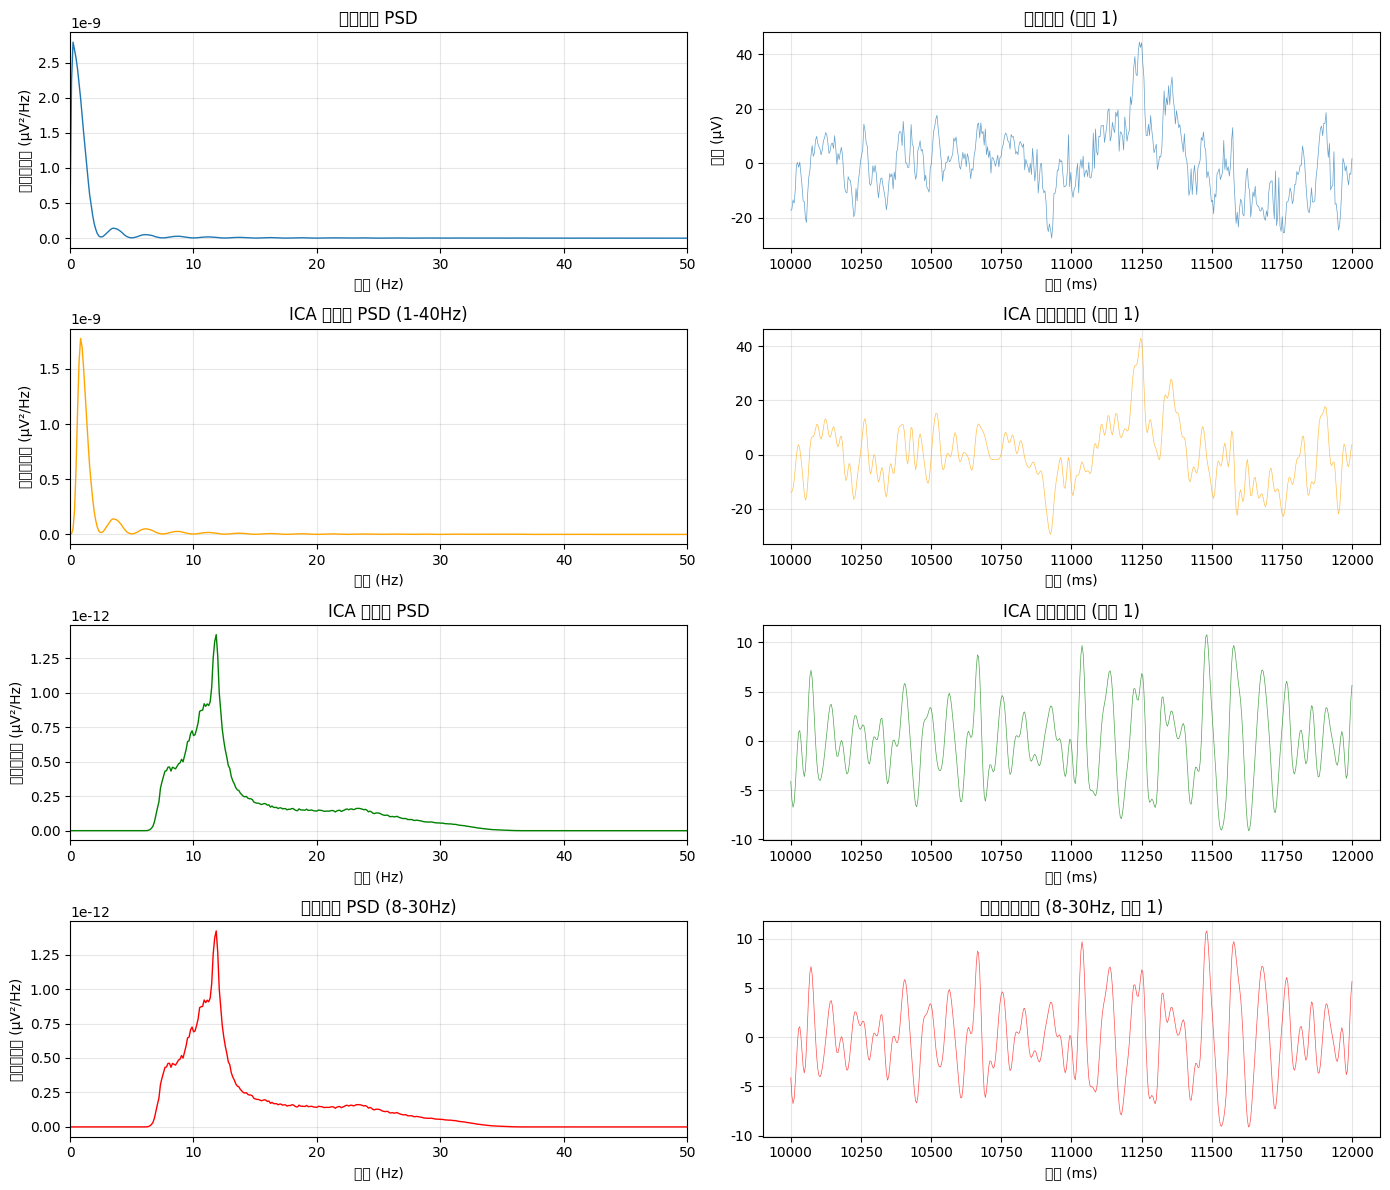

In [7]:
print("\n【Step 2】EEG 预处理")

epochs, ica = complete_preprocessing_pipeline(subject=subject_id)

print(f"✅ 预处理完成")
print(f"   - Epochs 形状：{epochs.get_data().shape}")
print(f"   - 试次数：{len(epochs)}")
print(f"   - 通道数：{len(epochs.ch_names)}")

## Step 3: 特征提取


【Step 3】特征提取

CSP 特征提取
   - 输入数据形状：(273, 25, 1001)
   - 试次数：273
   - 通道数：25
   - 类别数：4
   - CSP 成分数：4
✅ CSP 滤波器训练完成
   - 滤波器形状：(4, 25)
✅ CSP 特征提取完成
   - 特征形状：(273, 4)



绘制 CSP 拓扑图...
⚠️  无法绘制 CSP 拓扑图：No digitization points found.

小波能量特征提取
   - 输入数据形状：(273, 25, 1001)
   - 试次数：273
   - 通道数：25
   - 小波基：db4
   - 分解层数：4

   各层对应频段:
   - Level 1 (A): 0.0-7.8 Hz
   - Level 2 (D4): 7.8-15.6 Hz
   - Level 3 (D3): 15.6-31.2 Hz
   - Level 4 (D2): 31.2-62.5 Hz
   - Level 5 (D1): 62.5-125.0 Hz



✅ 小波能量特征提取完成
   - 特征形状：(273, 125)
   - 每个试次特征数：125

特征标准化 (Z-score)
   - 训练集形状：(273, 4) → (273, 4)
   - 均值：0.000000 (应接近 0)
   - 标准差：1.000000 (应接近 1)
✅ 训练集标准化完成

特征标准化 (Z-score)
   - 训练集形状：(273, 125) → (273, 125)
   - 均值：-0.000000 (应接近 0)
   - 标准差：1.000000 (应接近 1)
✅ 训练集标准化完成
✅ 特征提取完成
   - CSP 特征形状：(273, 4)
   - 小波特征形状：(273, 125)


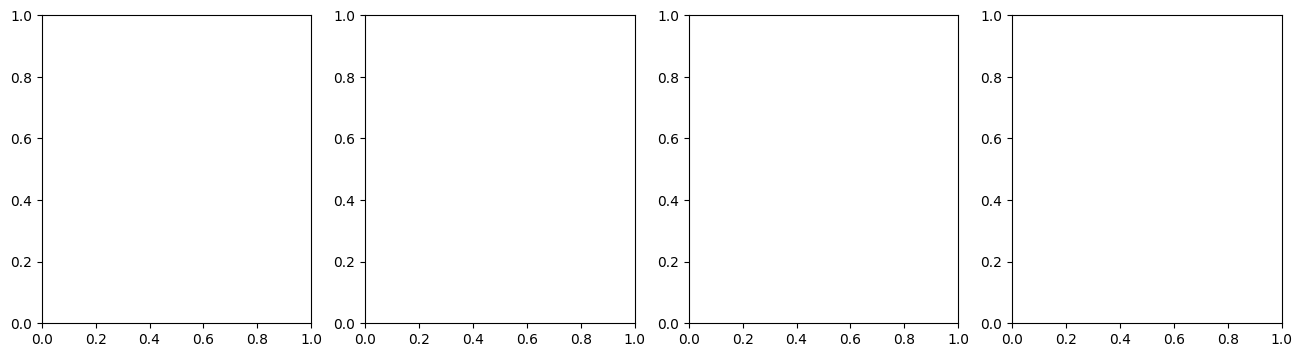

In [8]:
print("\n【Step 3】特征提取")

# 3.1 CSP 特征
X_csp, csp = extract_csp_features(epochs, n_components=4)

# 可视化 CSP 拓扑图
try:
    visualize_csp_topo(
        csp, epochs, save_path=f"./{subject_id}_csp_topo.png")
except Exception as e:
    print(f"⚠️  无法绘制 CSP 拓扑图：{e}")

# 3.2 小波特征
X_wavelet = extract_wavelet_energy_features(epochs, wavelet="db4", level=4)

# 3.3 特征归一化
X_csp_norm, scaler_csp = normalize_features(X_csp)
X_wavelet_norm, scaler_wavelet = normalize_features(X_wavelet)

print(f"✅ 特征提取完成")
print(f"   - CSP 特征形状：{X_csp.shape}")
print(f"   - 小波特征形状：{X_wavelet.shape}")

## Step 4: 特征融合

In [9]:
print("\n【Step 4】特征融合")

# 简单拼接融合
X_fused = np.hstack([X_csp_norm, X_wavelet_norm])
print(f"   - CSP 特征：{X_csp_norm.shape}")
print(f"   - 小波特征：{X_wavelet_norm.shape}")
print(f"   - 融合特征：{X_fused.shape}")


【Step 4】特征融合
   - CSP 特征：(273, 4)
   - 小波特征：(273, 125)
   - 融合特征：(273, 129)


## Step 5: 准备标签

In [10]:
print("\n【Step 5】准备标签")

# 从 epochs.events 中提取标签
y = epochs.events[:, 2]

# 显示标签分布
unique_labels, counts = np.unique(y, return_counts=True)
print(f"\n📊 标签分布:")
for label, count in zip(unique_labels, counts):
    label_name = {769: '左手', 770: '右手', 771: '双脚', 772: '舌头'}.get(label, '未知')
    print(f"   - {label} ({label_name}): {count} 个")

# 检查是否有非任务标签
valid_labels = [769, 770, 771, 772]
invalid_mask = ~np.isin(y, valid_labels)
if np.any(invalid_mask):
    n_invalid = np.sum(invalid_mask)
    invalid_labels = np.unique(y[invalid_mask])
    print(f"\n⚠️  警告：发现 {n_invalid} 个非任务标签：{invalid_labels}")
    print(f"   这些标签将在训练时被排除...")

print(f"\n✅ 标签形状：{y.shape}")


【Step 5】准备标签

📊 标签分布:
   - 7 (未知): 69 个
   - 8 (未知): 69 个
   - 9 (未知): 68 个
   - 10 (未知): 67 个

⚠️  警告：发现 273 个非任务标签：[ 7  8  9 10]
   这些标签将在训练时被排除...

✅ 标签形状：(273,)


## Step 6: SVM 分类器训练与评估

In [11]:
print("\n【Step 6】SVM 分类器训练与评估")

# 6.1 仅使用 CSP 特征
print("\n--- 使用 CSP 特征 ---")
clf_csp, cv_scores_csp, acc_csp = train_svm_classifier(X_csp_norm, y)

# 6.2 仅使用小波特征
print("\n--- 使用小波特征 ---")
clf_wavelet, cv_scores_wavelet, acc_wavelet = train_svm_classifier(
    X_wavelet_norm, y
)

# 6.3 使用融合特征
print("\n--- 使用融合特征 ---")
clf_fused, cv_scores_fused, acc_fused = train_svm_classifier(X_fused, y)


【Step 6】SVM 分类器训练与评估

--- 使用 CSP 特征 ---

SVM 分类器训练
   - 特征矩阵形状：(273, 4)
   - 样本数：273
   - 特征数：4
   - 类别分布：[ 0  0  0  0  0  0  0 69 69 68 67]
   - 交叉验证折数：10
   - 核函数：rbf

✅ SVM 训练完成
   - 交叉验证准确率：0.7217 ± 0.0604
   - 各折得分：[0.6071 0.8214 0.7143 0.7037 0.7037 0.7407 0.7407 0.6667 0.7037 0.8148]

--- 使用小波特征 ---

SVM 分类器训练
   - 特征矩阵形状：(273, 125)
   - 样本数：273
   - 特征数：125
   - 类别分布：[ 0  0  0  0  0  0  0 69 69 68 67]
   - 交叉验证折数：10
   - 核函数：rbf

✅ SVM 训练完成
   - 交叉验证准确率：0.6821 ± 0.0562
   - 各折得分：[0.6071 0.6071 0.6071 0.7407 0.7037 0.6667 0.7037 0.7037 0.7778 0.7037]

--- 使用融合特征 ---

SVM 分类器训练
   - 特征矩阵形状：(273, 129)
   - 样本数：273
   - 特征数：129
   - 类别分布：[ 0  0  0  0  0  0  0 69 69 68 67]
   - 交叉验证折数：10
   - 核函数：rbf

✅ SVM 训练完成
   - 交叉验证准确率：0.6927 ± 0.0520
   - 各折得分：[0.6429 0.7143 0.6071 0.7407 0.7037 0.6667 0.7037 0.7407 0.7778 0.6296]


## Step 7: 结果汇总

In [12]:
print("\n【Step 7】结果汇总")

print("\n" + "=" * 60)
print("分类性能对比")
print("=" * 60)
print(f"CSP 特征准确率：     {acc_csp:.4f} ± {cv_scores_csp.std():.4f}")
print(f"小波特征准确率：   {acc_wavelet:.4f} ± {cv_scores_wavelet.std():.4f}")
print(f"融合特征准确率：   {acc_fused:.4f} ± {cv_scores_fused.std():.4f}")
print("=" * 60)

# 找出最佳特征
best_acc = max(acc_csp, acc_wavelet, acc_fused)
if best_acc == acc_fused:
    print(f"\n🏆 融合特征表现最佳！")
elif best_acc == acc_csp:
    print(f"\n🏆 CSP 特征表现最佳！")
else:
    print(f"\n🏆 小波特征表现最佳！")


【Step 7】结果汇总

分类性能对比
CSP 特征准确率：     0.7217 ± 0.0604
小波特征准确率：   0.6821 ± 0.0562
融合特征准确率：   0.6927 ± 0.0520

🏆 CSP 特征表现最佳！


## Step 8: 保存结果

In [13]:
print("\n【Step 8】保存结果")

results = {
    "subject_id": subject_id,
    "epochs": epochs,
    "ica": ica,
    "X_csp": X_csp,
    "X_wavelet": X_wavelet,
    "X_fused": X_fused,
    "y": y,
    "scaler_csp": scaler_csp,
    "scaler_wavelet": scaler_wavelet,
    "clf_csp": clf_csp,
    "clf_wavelet": clf_wavelet,
    "clf_fused": clf_fused,
    "metrics": {
        "csp": {
            "accuracy": acc_csp,
            "cv_scores": cv_scores_csp,
            "cv_mean": acc_csp,
            "cv_std": cv_scores_csp.std(),
        },
        "wavelet": {
            "accuracy": acc_wavelet,
            "cv_scores": cv_scores_wavelet,
            "cv_mean": acc_wavelet,
            "cv_std": cv_scores_wavelet.std(),
        },
        "fused": {
            "accuracy": acc_fused,
            "cv_scores": cv_scores_fused,
            "cv_mean": acc_fused,
            "cv_std": cv_scores_fused.std(),
        },
    },
}

print(f"✅ 结果已保存到 results 字典")


【Step 8】保存结果
✅ 结果已保存到 results 字典


## Step 9: 可视化（可选）

In [14]:
print("\n【Step 9】可视化（可选）")

# 绘制混淆矩阵（使用融合特征）
try:
    from sklearn.metrics import confusion_matrix
    
    y_pred = clf_fused.predict(X_fused)
    class_names = ["左手", "右手", "双脚", "舌头"]
    
    # 计算混淆矩阵
    cm = confusion_matrix(y, y_pred)
    
    # 绘制混淆矩阵图
    plot_confusion_matrix(
        cm,
        class_names=class_names,
        save_path=f"./{subject_id}_confusion_matrix.png",
    )
    print(f"✅ 混淆矩阵已保存：./{subject_id}_confusion_matrix.png")
except Exception as e:
    print(f"⚠️  无法绘制混淆矩阵：{e}")

/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 33050 (\N{CJK UNIFIED IDEOGRAPH-811A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



【Step 9】可视化（可选）

绘制混淆矩阵图...


/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 33292 (\N{CJK UNIFIED IDEOGRAPH-820C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:220: UserWarning: Glyph 22836 (\N{CJK UNIFIED IDEOGRAPH-5934}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:221: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:221: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/eliorfoy/code/Graduation-Design/code/classification/svm_classifier.py:221: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font

✅ 混淆矩阵图已保存：./A01T_confusion_matrix.png
✅ 混淆矩阵已保存：./A01T_confusion_matrix.png


## 完成

In [15]:
print("\n" + "=" * 80)
print(f"✅ 单被试 {subject_id} 完整流程处理完成！")
print("=" * 80)

# 显示最终结果摘要
print(f"\n📊 被试：{results['subject_id']}")
print(f"📈 最终试次数：{len(results['epochs'])}")
print(f"🔌 通道数：{len(results['epochs'].ch_names)}")

print(f"\n特征维度:")
print(f"  - CSP 特征：{results['X_csp'].shape}")
print(f"  - 小波特征：{results['X_wavelet'].shape}")
print(f"  - 融合特征：{results['X_fused'].shape}")

print(f"\n分类准确率:")
print(f"  - CSP 特征：{results['metrics']['csp']['cv_mean']:.4f} ± {results['metrics']['csp']['cv_std']:.4f}")
print(f"  - 小波特征：{results['metrics']['wavelet']['cv_mean']:.4f} ± {results['metrics']['wavelet']['cv_std']:.4f}")
print(f"  - 融合特征：{results['metrics']['fused']['cv_mean']:.4f} ± {results['metrics']['fused']['cv_std']:.4f}")

# 找出最佳方法
best_method = max(
    results['metrics'].items(),
    key=lambda x: x[1]['cv_mean']
)
print(f"\n🏆 最佳方法：{best_method[0].upper()} (准确率：{best_method[1]['cv_mean']:.4f})")


✅ 单被试 A01T 完整流程处理完成！

📊 被试：A01T
📈 最终试次数：273
🔌 通道数：25

特征维度:
  - CSP 特征：(273, 4)
  - 小波特征：(273, 125)
  - 融合特征：(273, 129)

分类准确率:
  - CSP 特征：0.7217 ± 0.0604
  - 小波特征：0.6821 ± 0.0562
  - 融合特征：0.6927 ± 0.0520

🏆 最佳方法：CSP (准确率：0.7217)
